In [5]:
print(df.columns)


Index(['Disease', 'Symptom_1', 'Symptom_2', 'Symptom_3', 'Symptom_4',
       'Symptom_5', 'Symptom_6', 'Symptom_7', 'Symptom_8', 'Symptom_9',
       'Symptom_10', 'Symptom_11', 'Symptom_12', 'Symptom_13', 'Symptom_14',
       'Symptom_15', 'Symptom_16', 'Symptom_17'],
      dtype='object')



Classification Report:
                                          precision    recall  f1-score   support

(vertigo) Paroymsal  Positional Vertigo       1.00      1.00      1.00        18
                                   AIDS       1.00      1.00      1.00        30
                                   Acne       1.00      1.00      1.00        24
                    Alcoholic hepatitis       1.00      1.00      1.00        25
                                Allergy       1.00      1.00      1.00        24
                              Arthritis       1.00      1.00      1.00        23
                       Bronchial Asthma       1.00      1.00      1.00        33
                   Cervical spondylosis       1.00      1.00      1.00        23
                            Chicken pox       1.00      1.00      1.00        21
                    Chronic cholestasis       1.00      1.00      1.00        15
                            Common Cold       1.00      1.00      1.00        23
  

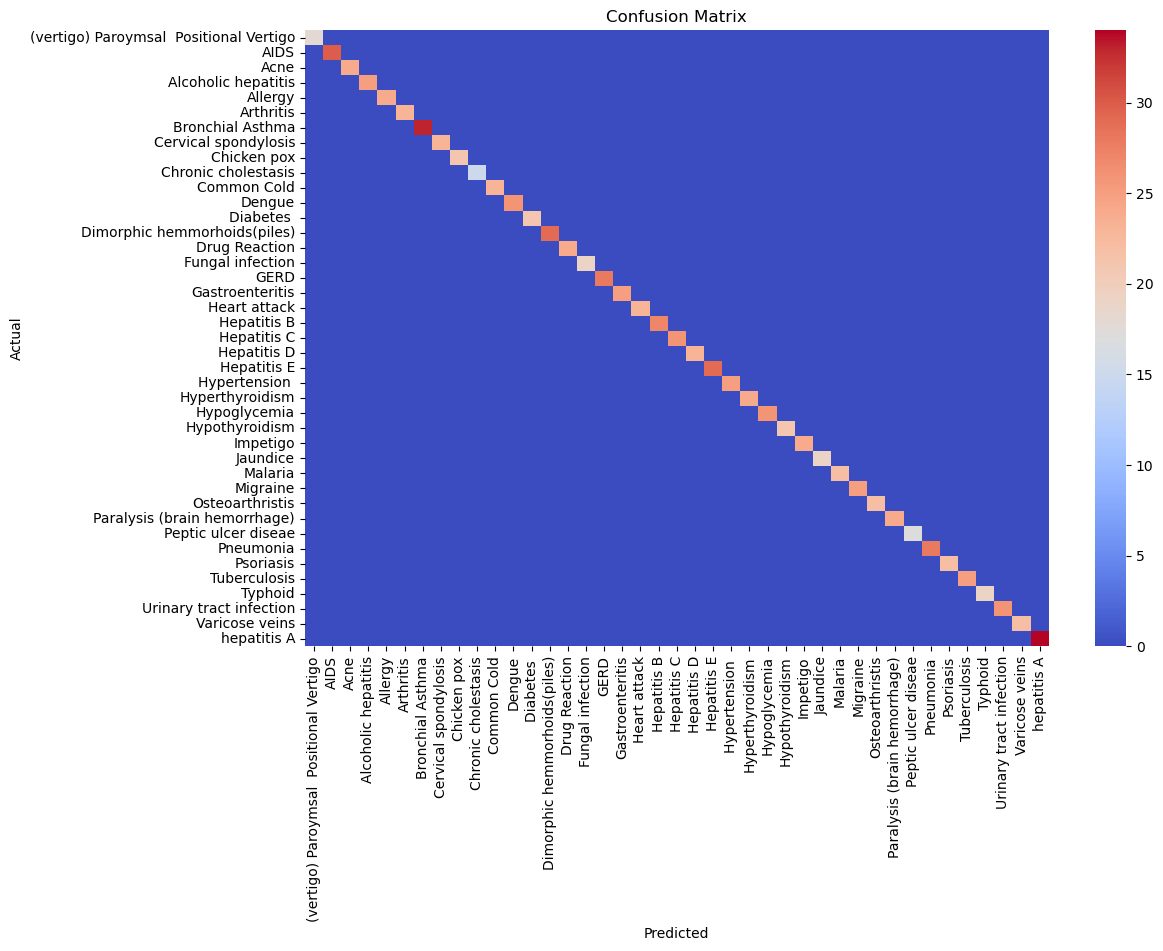

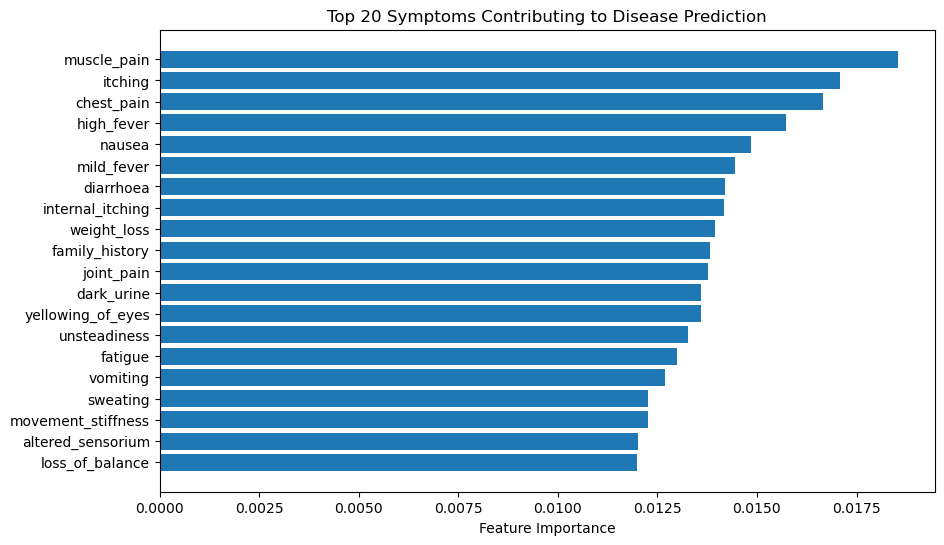

In [6]:
# disease_prediction_multi_symptom.py

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# 1. Load the dataset
df = pd.read_csv("dataset.csv")  # Replace with your actual filename

# 2. Clean column names (optional)
df.columns = df.columns.str.strip()

# 3. Combine all symptom columns into a list
symptom_cols = [col for col in df.columns if col.startswith('Symptom')]
df['Symptoms'] = df[symptom_cols].values.tolist()

# 4. Clean symptoms: remove NaNs and lowercase
df['Symptoms'] = df['Symptoms'].apply(lambda x: [str(sym).strip().lower() for sym in x if str(sym).lower() != 'nan'])

# 5. One-hot encode the symptoms
mlb = MultiLabelBinarizer()
symptom_data = pd.DataFrame(mlb.fit_transform(df['Symptoms']), columns=mlb.classes_)

# 6. Combine with the target
data = pd.concat([symptom_data, df['Disease']], axis=1)

# 7. Features and target
X = data.drop('Disease', axis=1)
y = data['Disease']

# 8. Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 9. Model training
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 10. Prediction
y_pred = model.predict(X_test)

# 11. Evaluation
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))

# 12. Confusion Matrix
plt.figure(figsize=(12, 8))
cm = confusion_matrix(y_test, y_pred, labels=np.unique(y))
sns.heatmap(cm, annot=False, fmt='d', xticklabels=np.unique(y), yticklabels=np.unique(y), cmap='coolwarm')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 13. Feature Importance
importances = model.feature_importances_
indices = np.argsort(importances)[-20:]

plt.figure(figsize=(10, 6))
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [X.columns[i] for i in indices])
plt.xlabel('Feature Importance')
plt.title('Top 20 Symptoms Contributing to Disease Prediction')
plt.show()
